# Benchmarking compression efficiency across different models

> ### Reproducibility &amp; data
>
> This notebook reproduces the cross-architecture benchmark comparison from the in-repo `saved_data/` caches (incl. `../../simulations/VAE_gLV_simulation/saved_data/`).
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

# Fixed simulations
We first examine the compression efficiency on the `fixed` background simulations.

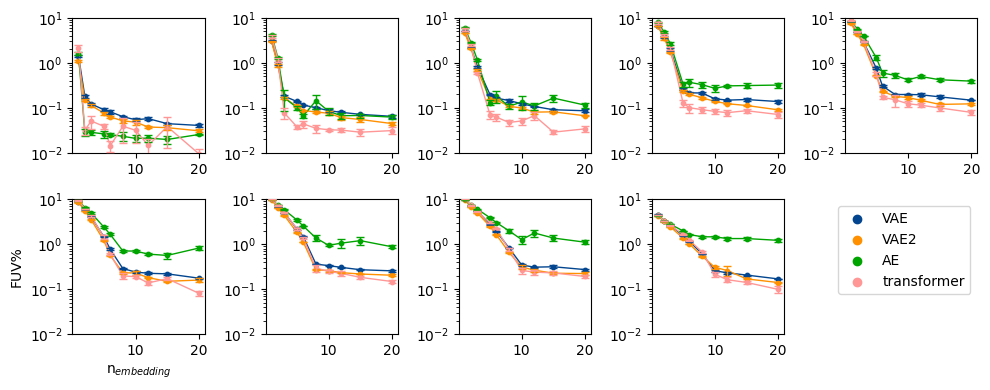

In [13]:
colors = ['#03468F', '#FF9000','#00A400','#FF9797','#808080',]
labels = ["VAE", "VAE2", "AE", "transformer"]
NT=np.arange(2,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="fixed"
model_index=3
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data1=np.loadtxt(f"../../simulations/VAE_gLV_simulation/saved_data/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data2=np.loadtxt(f"./saved_data/VAE_dl/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data3=np.loadtxt(f"./saved_data/AE/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    data4=np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/I{model_index}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    for j,data in enumerate([data1, data2, data3, data4]):
        N_EBD=data[0,:]
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        ax.scatter(N_EBD,mean_FUV,s=10,c=colors[j],label=labels[j])
        ax.plot(N_EBD,mean_FUV,linewidth=1,c=colors[j])
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',c=colors[j],elinewidth=1,capsize=3,zorder=10)
    ax.set_yscale("log")
    ax.set_ylim([0.01,10])
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
ax=axes[-1]
for i, label in enumerate(labels):
    ax.scatter([], [], c=colors[i], label=label)
ax.legend()
ax.axis('off')
fig.tight_layout()